<a href="https://colab.research.google.com/github/divyadharshini-1306/ShiftSafeAI/blob/main/ShiftSafeAI_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Always the first cell in every Colab notebook
# This connects your Google Drive so you can access your saved files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the clean file we saved yesterday — not the raw one
# This is the file with 20 columns, zero missing values, all features engineered
df = pd.read_csv('/content/drive/MyDrive/ShiftSafe_AI/EDA/blr_clean.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Quick sanity check — confirm we loaded the right file
print(f"Shape: {df.shape}")
print(f"Date range: {df['Datetime'].min()} → {df['Datetime'].max()}")
print(f"Missing values: {df.isnull().sum().sum()}")

Shape: (48189, 20)
Date range: 2015-01-01 04:00:00 → 2020-07-01 00:00:00
Missing values: 0


In [ ]:
# This sets the visual style for ALL plots in this notebook
# 'whitegrid' gives clean white background with light grid lines
# Makes plots look professional and easy to read
# figsize sets default plot dimensions (width x height in inches)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print("Plot style set. Ready to visualise.")

Plot style set. Ready to visualise.


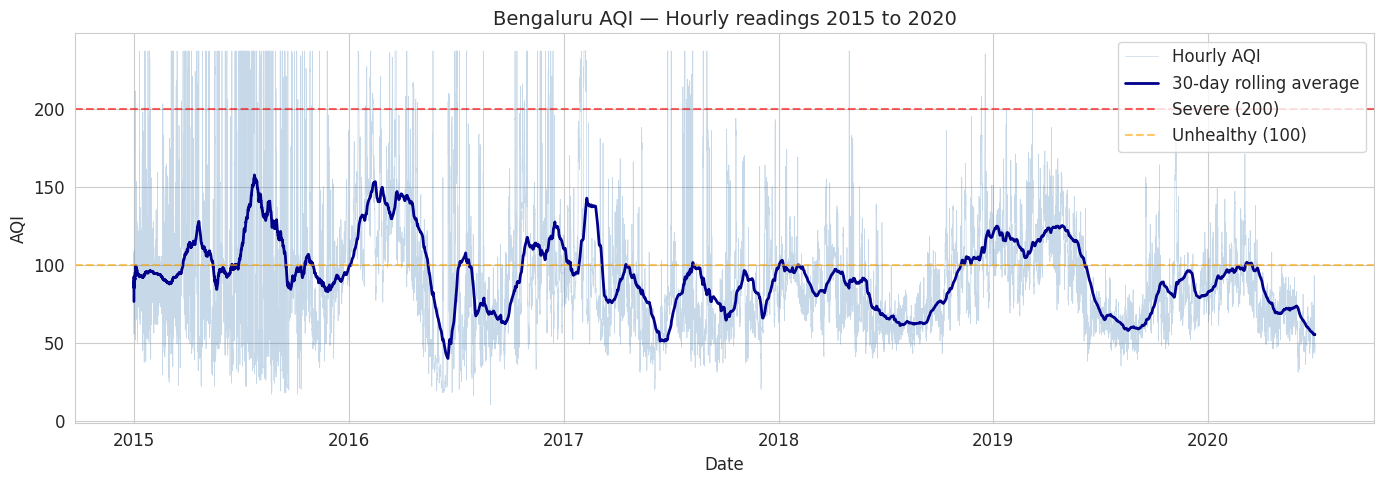

Average AQI across all hours: 93.1
Worst AQI recorded: 237.0
Best AQI recorded:  10.0
Hours above 200 (Severe): 2018 hrs (4.2%)
Hours above 100 (Unhealthy): 15269 hrs (31.7%)


In [ ]:
# PLOT 1 — AQI over time (the full 5.5 year story)
#
# What this plot shows:
# The complete trajectory of Bengaluru AQI from 2015 to 2020, hour by hour.
# Because hourly data is noisy (spiky), we also overlay a 30-day rolling
# average as a smooth line — this reveals the seasonal trend underneath the noise.
#
# What to look for in the output:
# - Peaks every Oct–Feb (winter months = worse AQI due to temperature inversion)
# - Dips every Jun–Sep (monsoon = rain washes pollution out)
# - Any sudden extreme spikes (Diwali, dust storms)
# - Whether AQI has been getting better or worse over the years
# - The red dashed line at AQI=200 is the "Severe" threshold
# - The orange dashed line at AQI=100 is the "Unhealthy" threshold

fig, ax = plt.subplots(figsize=(14, 5))

# Plot raw hourly AQI as a thin, semi-transparent line
# alpha=0.3 makes it light so it doesn't overwhelm the smooth trend line
ax.plot(df['Datetime'], df['AQI'],
        color='steelblue', linewidth=0.5, alpha=0.3, label='Hourly AQI')

# Plot 30-day (720 hour) rolling average as a bold line on top
# This smooths out the hour-to-hour noise and shows the real seasonal trend
rolling_avg = df['AQI'].rolling(window=720, min_periods=1).mean()
ax.plot(df['Datetime'], rolling_avg,
        color='darkblue', linewidth=2, label='30-day rolling average')

# Add horizontal threshold lines for visual reference
# These are India's official AQI category boundaries
ax.axhline(200, color='red',    linestyle='--', alpha=0.6, label='Severe (200)')
ax.axhline(100, color='orange', linestyle='--', alpha=0.6, label='Unhealthy (100)')

ax.set_title('Bengaluru AQI — Hourly readings 2015 to 2020', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('AQI')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Print a quick summary of what the plot is showing numerically
print(f"Average AQI across all hours: {df['AQI'].mean():.1f}")
print(f"Worst AQI recorded: {df['AQI'].max():.1f}")
print(f"Best AQI recorded:  {df['AQI'].min():.1f}")
print(f"Hours above 200 (Severe): {(df['AQI'] > 200).sum()} hrs ({(df['AQI'] > 200).mean()*100:.1f}%)")
print(f"Hours above 100 (Unhealthy): {(df['AQI'] > 100).sum()} hrs ({(df['AQI'] > 100).mean()*100:.1f}%)")

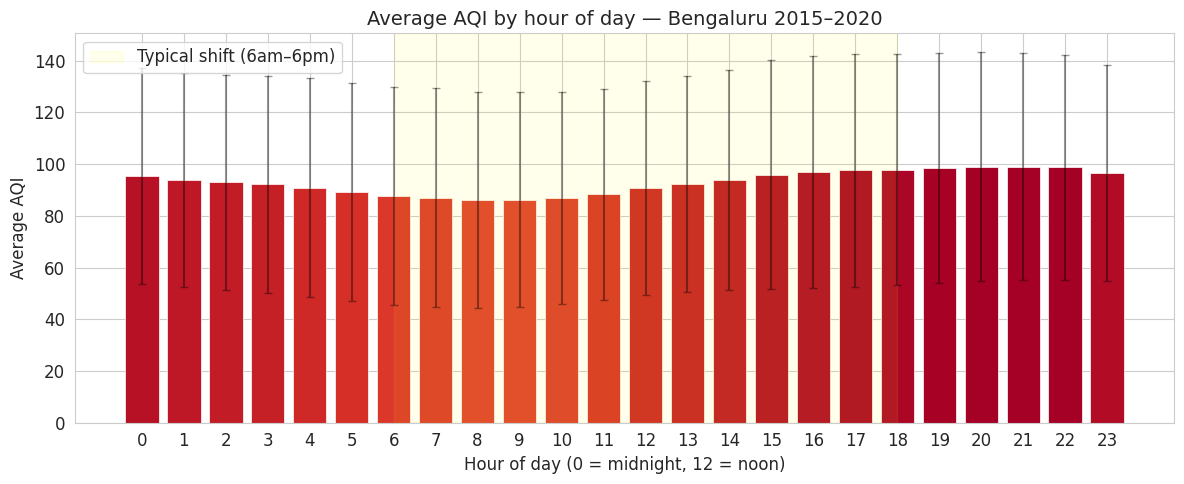

Top 5 worst hours for AQI (highest exposure risk for workers):
 hour      mean
   20 99.073534
   21 99.022040
   22 98.765772
   19 98.454709
   18 97.845148

Top 5 best hours for AQI (lowest exposure risk):
 hour      mean
    8 86.144048
    9 86.275917
   10 86.850320
    7 87.085789
    6 87.670556


In [ ]:
# PLOT 2 — Average AQI by hour of day
#
# What this plot shows:
# The average AQI for each hour across all 5.5 years of data.
# Hour 0 = midnight, Hour 6 = 6am, Hour 12 = noon, Hour 18 = 6pm.
#
# This is the most important plot for YOUR PROJECT specifically.
# It answers: does the hour of a worker's shift actually matter?
# If AQI at 8am is significantly higher than at 2pm,
# that directly justifies ShiftSafe AI's shift scheduling feature.
#
# What to look for:
# - A morning peak around 7–9am (rush hour + industrial startup)
# - A possible evening peak around 6–8pm (traffic + cooking emissions)
# - Lower values during afternoon (wind disperses pollution)
# - Lowest values at night (minimal traffic, less human activity)
# The shaded area shows the standard deviation — how much AQI varies at each hour

# Group by hour and calculate mean and std deviation of AQI
hourly_stats = df.groupby('hour')['AQI'].agg(['mean', 'std']).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))

# Bar chart of average AQI per hour
# Color each bar by its average value — darker = worse AQI
bars = ax.bar(hourly_stats['hour'], hourly_stats['mean'],
              color=plt.cm.RdYlGn_r(hourly_stats['mean'] / hourly_stats['mean'].max()),
              edgecolor='white', linewidth=0.5)

# Overlay standard deviation as error bars
# This shows how much AQI varies at each hour — wider = less predictable
ax.errorbar(hourly_stats['hour'], hourly_stats['mean'],
            yerr=hourly_stats['std'],
            fmt='none', color='black', alpha=0.4, capsize=3)

# Shade the typical work shift window (6am to 6pm) in light yellow
# This visually highlights which hours workers are actually exposed
ax.axvspan(6, 18, alpha=0.08, color='yellow', label='Typical shift (6am–6pm)')

ax.set_title('Average AQI by hour of day — Bengaluru 2015–2020', fontsize=14)
ax.set_xlabel('Hour of day (0 = midnight, 12 = noon)')
ax.set_ylabel('Average AQI')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

# Print the best and worst hours numerically
print("Top 5 worst hours for AQI (highest exposure risk for workers):")
print(hourly_stats.nlargest(5, 'mean')[['hour', 'mean']].to_string(index=False))
print("\nTop 5 best hours for AQI (lowest exposure risk):")
print(hourly_stats.nsmallest(5, 'mean')[['hour', 'mean']].to_string(index=False))

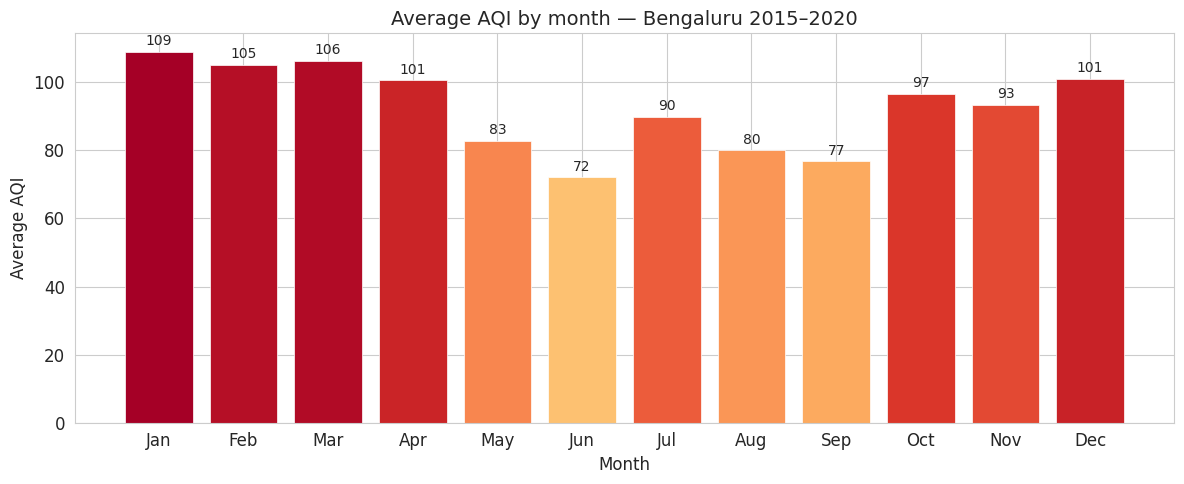

Winter average AQI  (Oct–Feb): 101.5
Monsoon average AQI (Jun–Sep): 79.5
Seasonal difference: 22.0 AQI points


In [ ]:
# PLOT 3 — Average AQI by month (seasonal pattern)
#
# What this plot shows:
# The average AQI for each calendar month across all years.
# This reveals the seasonal cycle of Bengaluru's air quality.
#
# What to look for:
# - Higher AQI in Oct, Nov, Dec, Jan, Feb (winter months)
#   Reason: Cold air traps pollution near the ground (temperature inversion)
# - Lower AQI in Jun, Jul, Aug, Sep (monsoon months)
#   Reason: Rain physically washes PM2.5 and PM10 out of the atmosphere
# - This seasonal pattern is why 'month' is one of your model features —
#   a model that knows it's December will predict higher AQI than one that doesn't

month_stats = df.groupby('month')['AQI'].agg(['mean', 'std']).reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(12, 5))

# Color bars by AQI level — red = high pollution months, green = clean months
colors = plt.cm.RdYlGn_r(month_stats['mean'] / month_stats['mean'].max())
bars = ax.bar(month_names, month_stats['mean'],
              color=colors, edgecolor='white', linewidth=0.5)

# Add the actual average AQI value on top of each bar
# So you can read the exact number without squinting at the y-axis
for bar, val in zip(bars, month_stats['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10)

ax.set_title('Average AQI by month — Bengaluru 2015–2020', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Average AQI')
plt.tight_layout()
plt.show()

# Print the seasonal contrast numerically
winter_months = df[df['month'].isin([10,11,12,1,2])]['AQI'].mean()
monsoon_months = df[df['month'].isin([6,7,8,9])]['AQI'].mean()
print(f"Winter average AQI  (Oct–Feb): {winter_months:.1f}")
print(f"Monsoon average AQI (Jun–Sep): {monsoon_months:.1f}")
print(f"Seasonal difference: {winter_months - monsoon_months:.1f} AQI points")

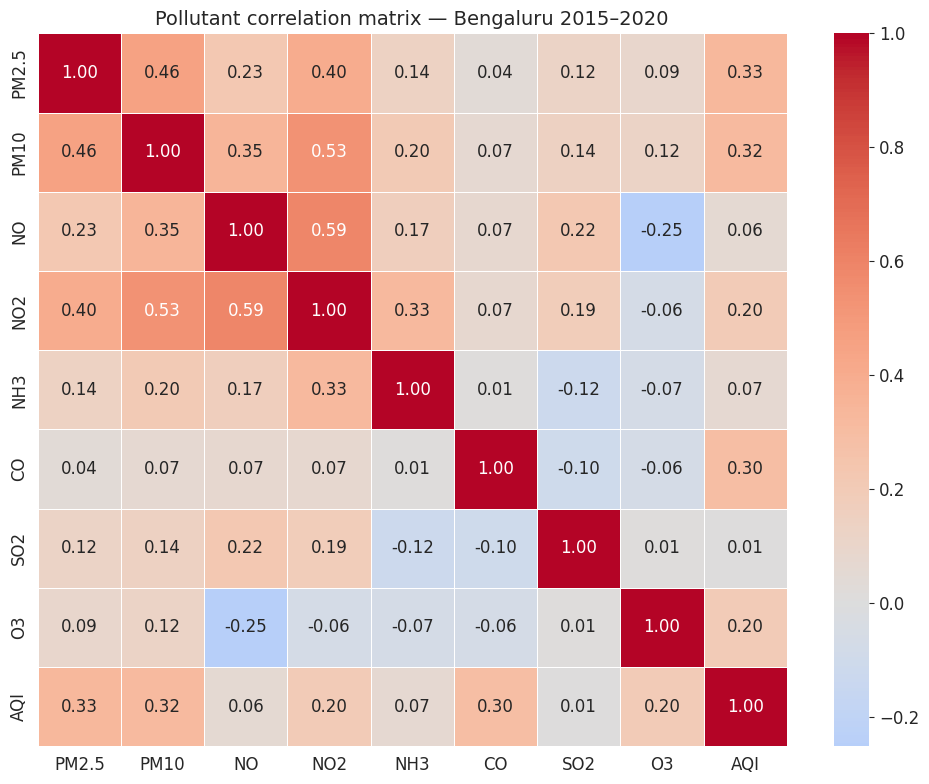

Pollutant correlations with AQI (strongest first):
PM2.5    0.334
PM10     0.319
CO       0.296
O3       0.199
NO2      0.195
NH3      0.067
NO       0.060
SO2      0.006
Name: AQI, dtype: float64

Strongest predictor of AQI: PM2.5 (correlation = 0.334)


In [ ]:
# PLOT 4 — Correlation heatmap
#
# What this plot shows:
# How strongly each pollutant moves with every other pollutant.
# The value in each cell ranges from -1 to +1:
# - +1.0 = perfect positive correlation (both go up and down together)
# -  0.0 = no relationship at all
# - -1.0 = perfect negative correlation (one goes up when other goes down)
#
# What to look for:
# - PM2.5 and PM10 should be strongly correlated (both are particulate matter)
# - NO and NO2 should correlate (related gases from combustion)
# - Most importantly: which column correlates MOST with AQI?
#   That is your most powerful predictive feature.
# - O3 (ozone) sometimes shows NEGATIVE correlation with NO
#   because NO chemically destroys ozone — this is called ozone titration.
#   If you see a negative value there, that's real atmospheric chemistry, not an error.

# Select only the pollutant columns for the heatmap
# We exclude time/engineered columns since we want raw pollutant relationships
pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NH3', 'CO', 'SO2', 'O3', 'AQI']
corr_matrix = df[pollutant_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))

# annot=True prints the correlation number inside each cell
# fmt='.2f' formats it to 2 decimal places
# cmap='coolwarm' — blue = negative correlation, red = positive correlation
sns.heatmap(corr_matrix,
            annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='white',
            ax=ax)

ax.set_title('Pollutant correlation matrix — Bengaluru 2015–2020', fontsize=14)
plt.tight_layout()
plt.show()

# Print the single most important finding from this heatmap:
# Which pollutant has the strongest relationship with AQI?
aqi_correlations = corr_matrix['AQI'].drop('AQI').abs().sort_values(ascending=False)
print("Pollutant correlations with AQI (strongest first):")
print(aqi_correlations.round(3))
print(f"\nStrongest predictor of AQI: {aqi_correlations.index[0]} "
      f"(correlation = {aqi_correlations.iloc[0]:.3f})")

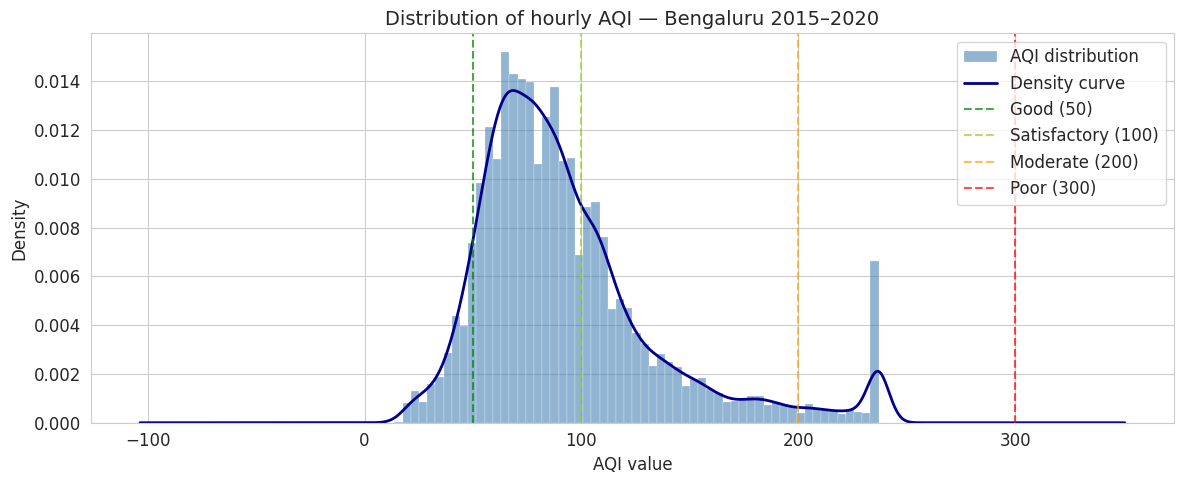

Hours in each AQI category:
  Good         (0–50):   8.9%
  Satisfactory (51–100): 59.4%
  Moderate     (101–200):27.5%
  Poor         (201–300):4.2%
  Severe       (300+):   0.0%


In [ ]:
# PLOT 5 — AQI distribution (histogram + density curve)
#
# What this plot shows:
# The shape of AQI values across all 48,189 hours.
# Are most hours "Good" AQI or "Moderate" or "Unhealthy"?
# Is the distribution symmetric or skewed?
#
# What to look for:
# - If the peak is between 50–100, most of Bengaluru's hours are "Moderate"
# - If the tail extends far right, there are significant high-pollution events
# - A right-skewed distribution (tail on the right) is typical for AQI data
#   It means extreme pollution events are real but relatively rare
#
# The vertical coloured lines show India's official AQI category boundaries:
# 0–50 = Good (green), 51–100 = Satisfactory, 101–200 = Moderate,
# 201–300 = Poor, 301–400 = Very Poor, 401+ = Severe

fig, ax = plt.subplots(figsize=(12, 5))

# Plot histogram with 50 bins
# kde=True overlays a smooth density curve on top
ax.hist(df['AQI'], bins=60, color='steelblue', alpha=0.6,
        edgecolor='white', linewidth=0.3, density=True, label='AQI distribution')

# Overlay smooth KDE (Kernel Density Estimate) curve
df['AQI'].plot.kde(ax=ax, color='darkblue', linewidth=2, label='Density curve')

# Add vertical lines for each AQI category boundary
category_lines = {
    'Good (50)':       (50,  'green'),
    'Satisfactory (100)': (100, 'yellowgreen'),
    'Moderate (200)':  (200, 'orange'),
    'Poor (300)':      (300, 'red'),
}
for label, (val, color) in category_lines.items():
    ax.axvline(val, color=color, linestyle='--', alpha=0.7, linewidth=1.5, label=label)

ax.set_title('Distribution of hourly AQI — Bengaluru 2015–2020', fontsize=14)
ax.set_xlabel('AQI value')
ax.set_ylabel('Density')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Print the % of hours in each AQI category
# This tells you the real-world pollution profile of Bengaluru
print("Hours in each AQI category:")
print(f"  Good         (0–50):   {(df['AQI'] <= 50).mean()*100:.1f}%")
print(f"  Satisfactory (51–100): {((df['AQI'] > 50)  & (df['AQI'] <= 100)).mean()*100:.1f}%")
print(f"  Moderate     (101–200):{((df['AQI'] > 100) & (df['AQI'] <= 200)).mean()*100:.1f}%")
print(f"  Poor         (201–300):{((df['AQI'] > 200) & (df['AQI'] <= 300)).mean()*100:.1f}%")
print(f"  Severe       (300+):   {(df['AQI'] > 300).mean()*100:.1f}%")